<a href="https://colab.research.google.com/github/NavaneethAshok/NPK_RF_CATB_ENSEMBLE/blob/main/npkpredictionensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install catboost -q
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from catboost import CatBoostClassifier
import joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


In [2]:
!pip install kagglehub[pandas-datasets] -q

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Crop_recommendation.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "atharvaingle/crop-recommendation-dataset",
    file_path,
)

print(df.shape)
df.head()


/tmp/ipykernel_11180/1770928471.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 147k/147k [00:00<00:00, 1.03MB/s]

(2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
!pip install kagglehub[pandas-datasets] catboost -q

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from catboost import CatBoostClassifier


In [4]:
file_path = "Crop_recommendation.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "atharvaingle/crop-recommendation-dataset",
    file_path,
)

print(df.head())
print(df.isnull().sum())
print(df["label"].nunique())


/tmp/ipykernel_11180/2934824946.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
22


In [5]:
X = df.drop("label", axis=1)
y = df["label"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)


In [6]:
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("RandomForest Accuracy:", accuracy_score(y_test, rf_pred))


RandomForest Accuracy: 0.9954545454545455


In [7]:
cb = CatBoostClassifier(
    iterations=800,
    learning_rate=0.1,
    depth=6,
    loss_function="MultiClass",
    verbose=0,
    random_state=42
)
cb.fit(X_train, y_train)

cb_pred = cb.predict(X_test).astype(int).flatten()
print("CatBoost Accuracy:", accuracy_score(y_test, cb_pred))


CatBoost Accuracy: 0.9931818181818182


In [8]:
ensemble = VotingClassifier(
    estimators=[("rf", rf), ("cb", cb)],
    voting="soft"
)

ensemble.fit(X_train, y_train)
ens_pred = ensemble.predict(X_test)

print("Ensemble Accuracy:", accuracy_score(y_test, ens_pred))
print(classification_report(y_test, ens_pred))


Ensemble Accuracy: 0.9977272727272727
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00

In [9]:
joblib.dump(ensemble, "ensemble_crop_model.pkl")
joblib.dump(le, "label_encoder.pkl")


['label_encoder.pkl']

In [10]:
from google.colab import files
files.download("ensemble_crop_model.pkl")
files.download("label_encoder.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [12]:
print("===== CatBoost Evaluation =====")

accuracy = accuracy_score(y_test, cb_pred)
precision = precision_score(y_test, cb_pred, average='weighted')
recall = recall_score(y_test, cb_pred, average='weighted')
f1 = f1_score(y_test, cb_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, cb_pred))


===== CatBoost Evaluation =====
Accuracy : 0.9931818181818182
Precision: 0.9935064935064936
Recall   : 0.9931818181818182
F1 Score : 0.9931162119865588

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       0.95      1.00      0.98        20
          10       1.00      1.00      1.00        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14

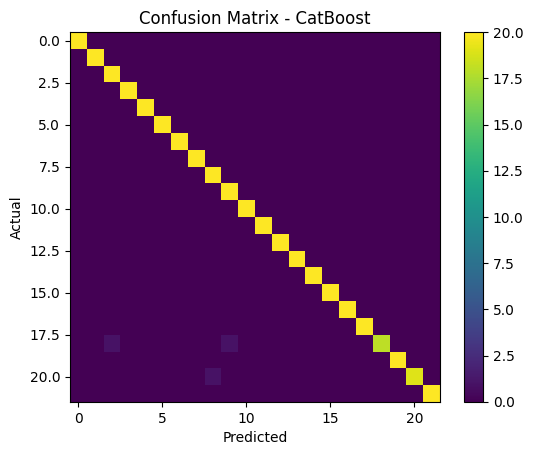

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, cb_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - CatBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


In [14]:
rf_pred = rf.predict(X_test)
cb_pred = cb.predict(X_test)
ens_pred = ensemble.predict(X_test)

rf_pred = rf_pred.flatten()
cb_pred = cb_pred.flatten()
ens_pred = ens_pred.flatten()


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [16]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n===== {name} =====")

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

    return accuracy, precision, recall, f1

In [17]:
rf_metrics = evaluate_model("Random Forest", y_test, rf_pred)
cb_metrics = evaluate_model("CatBoost", y_test, cb_pred)
ens_metrics = evaluate_model("Ensemble", y_test, ens_pred)



===== Random Forest =====
Accuracy : 0.9954545454545455
Precision: 0.9956709956709956
Recall   : 0.9954545454545455
F1 Score : 0.9954517027687759

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14     

In [18]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "CatBoost", "Ensemble"],
    "Accuracy": [rf_metrics[0], cb_metrics[0], ens_metrics[0]],
    "Precision": [rf_metrics[1], cb_metrics[1], ens_metrics[1]],
    "Recall": [rf_metrics[2], cb_metrics[2], ens_metrics[2]],
    "F1 Score": [rf_metrics[3], cb_metrics[3], ens_metrics[3]]
})

print(results)


           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest  0.995455   0.995671  0.995455  0.995452
1       CatBoost  0.993182   0.993506  0.993182  0.993116
2       Ensemble  0.997727   0.997835  0.997727  0.997726


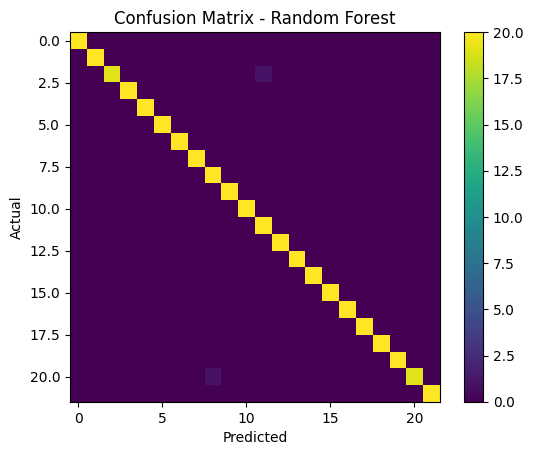

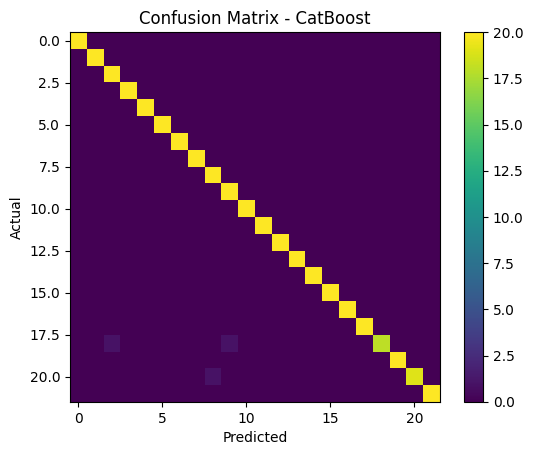

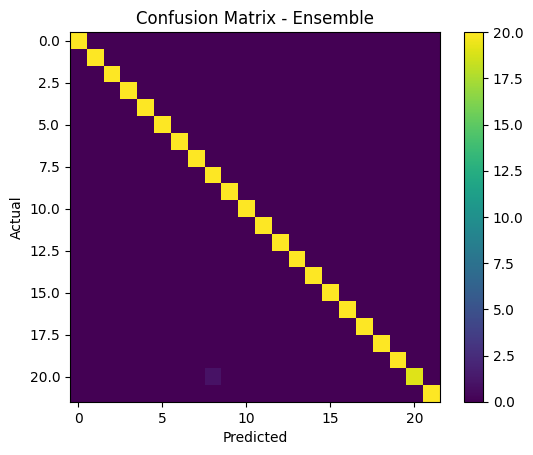

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()
    plt.show()

plot_confusion(y_test, rf_pred, "Confusion Matrix - Random Forest")
plot_confusion(y_test, cb_pred, "Confusion Matrix - CatBoost")
plot_confusion(y_test, ens_pred, "Confusion Matrix - Ensemble")


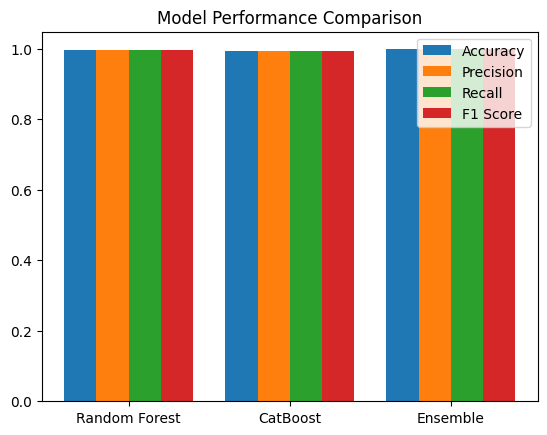

In [20]:
import numpy as np

plt.figure()

x = np.arange(len(results["Model"]))
width = 0.2

plt.bar(x - 1.5*width, results["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5*width, results["Precision"], width, label="Precision")
plt.bar(x + 0.5*width, results["Recall"], width, label="Recall")
plt.bar(x + 1.5*width, results["F1 Score"], width, label="F1 Score")

plt.xticks(x, results["Model"])
plt.title("Model Performance Comparison")
plt.legend()
plt.show()


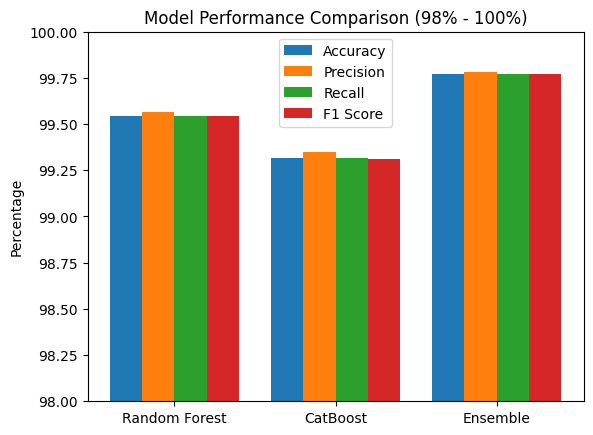

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Convert metrics to percentage
results_percent = results.copy()
results_percent["Accuracy"] *= 100
results_percent["Precision"] *= 100
results_percent["Recall"] *= 100
results_percent["F1 Score"] *= 100

plt.figure()

x = np.arange(len(results_percent["Model"]))
width = 0.2

plt.bar(x - 1.5*width, results_percent["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5*width, results_percent["Precision"], width, label="Precision")
plt.bar(x + 0.5*width, results_percent["Recall"], width, label="Recall")
plt.bar(x + 1.5*width, results_percent["F1 Score"], width, label="F1 Score")

plt.xticks(x, results_percent["Model"])
plt.ylim(98, 100)   # 🔥 Zoom between 98 and 100
plt.title("Model Performance Comparison (98% - 100%)")
plt.ylabel("Percentage")
plt.legend()

plt.show()

